# LSTM for ETF Cross-Asset Momentum

The LSTM tests whether temporal gating improves on the linear baseline
for 21-day ETF return prediction. Unlike TSMixer, LSTM processes each ETF's
feature history independently - it cannot learn cross-asset lead-lag
relationships (e.g., TLT leading equity volatility shifts). This makes it a
controlled baseline: any improvement over Ridge must come from temporal
dynamics within individual feature histories, not from cross-asset interactions.

**Learning Objectives**:
- Read the LSTM walk-forward checkpoint results from the frozen results registry
- Tune the checkpoint (epoch count) on validation, holdout sealed, under a
  full-coverage guard that excludes fold-collapsed checkpoints
- Determine whether temporal gating captures signal beyond linear lookback features
- Place the LSTM against the Ridge and GBM baselines on the same cross-section

**Book Reference**: Chapter 13, Section 13.8 (Case Study Results)

**Prerequisites**: [`06_linear`](06_linear.ipynb), [`07_gbm`](07_gbm.ipynb) (comparison baselines)

In [1]:
"""LSTM - etfs deep learning, checkpoints read from the frozen registry."""

import sqlite3
import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import yaml

from case_studies.utils.analytics import load_best_ic_per_family
from case_studies.utils.deep_learning import (
    _resolve_arch_name,
    create_model,
    run_dl_cv,
)
from case_studies.utils.registry import (
    build_training_spec,
    load_prediction_metrics,
    load_prediction_sets,
    training_hash_from_spec,
    training_run_status,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
MODEL = "lstm"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100
LOOKBACK = 60
BATCH_SIZE = 2048
MC_DROPOUT = False
MAX_FOLDS = 0

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]
    print(f"Label from setup.yaml: {PRIMARY_LABEL}")
else:
    print(f"Label override: {PRIMARY_LABEL}")

dl_config = setup.get("modeling", {}).get("dl", {})
DEVICE = dl_config.get("device", "gpu")

device_str = "cuda" if DEVICE == "gpu" and torch.cuda.is_available() else "cpu"
print(f"Case study: {CASE_STUDY_ID} | Model: {MODEL}")
print(f"Device: {device_str} | Epochs: {N_EPOCHS} | Lookback: {LOOKBACK}")

Label from setup.yaml: fwd_ret_21d
Case study: etfs | Model: lstm
Device: cuda | Epochs: 100 | Lookback: 60


## 1. Load Data

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits
if MAX_FOLDS:
    splits = splits[:MAX_FOLDS]
n_features = len(feature_names)

print(f"Dataset: {len(dataset):,} rows × {n_features} features")
print(f"Label: {label_col} | Entity: {entity_col} | Folds: {len(splits)}")

dataset_pd = dataset.to_pandas()
n_entities = dataset_pd[entity_col].nunique()
print(f"Entities: {n_entities}")

Dataset: 394,233 rows × 71 features
Label: fwd_ret_21d | Entity: symbol | Folds: 8
Entities: 99


## 2. Prior Baselines

Load IC results from earlier pipeline stages (Ch11 linear, Ch12 GBM)
rather than re-running them here.

In [5]:
prior_baselines = {}
_baselines = load_best_ic_per_family(["linear", "gbm"], case_studies=[CASE_STUDY_ID])
if not _baselines.is_empty():
    for row in _baselines.iter_rows(named=True):
        # The full-coverage linear leader is a Ridge config; label it plainly so
        # the comparison section (and its `.get("Ridge (Ch11)")`) resolves.
        if row["family"] == "linear":
            prior_baselines["Ridge (Ch11)"] = row["ic_mean"]
        elif row["family"] == "gbm":
            prior_baselines["GBM (Ch12)"] = row["ic_mean"]

if prior_baselines:
    for name, ic in prior_baselines.items():
        print(f"  {name}: IC={ic:+.4f}" if ic is not None else f"  {name}: IC=N/A")
else:
    print("  No prior results found - run 06_linear.py and 07_gbm.py first")

  GBM (Ch12): IC=+0.0440
  Ridge (Ch11): IC=+0.0420


## 3. LSTM

The results registry (`run_log/registry.db`) is the frozen source of truth for
this case study. The single LSTM config (`lstm_h64`) was trained walk-forward
with cross-sectional IC evaluated at epoch checkpoints, and every checkpoint is
stored as a validation prediction set with its IC. Here we read those
checkpoints back from the registry rather than retraining: on a cached checkout
no GPU work happens and the frozen registry is never rewritten. Only a config
with no registered validation predictions triggers a fresh `run_dl_cv` train.

In [6]:
dl_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "deep_learning")
dl_configs = [c for c in dl_configs if c["params"].get("architecture") == MODEL]

# Apply Papermill training overrides. N_EPOCHS / BATCH_SIZE / lookback are part of
# the training-spec hash, so they select which registered run to read: the frozen
# registry was built at N_EPOCHS=100, and changing it would miss the cache and
# trigger a fresh GPU train that rewrites the registry. Keep defaults for a cached
# read; overrides only bite in test mode on an uncached checkout.
for cfg in dl_configs:
    if cfg.get("n_epochs", 100) != N_EPOCHS:
        cfg["n_epochs"] = N_EPOCHS
    if cfg.get("batch_size", 2048) != BATCH_SIZE:
        cfg["batch_size"] = BATCH_SIZE
    if cfg["params"].get("lookback", 60) != LOOKBACK:
        cfg["params"]["lookback"] = LOOKBACK

print(f"Grid: {len(dl_configs)} config(s) × {len(splits)} folds (checkpoints read from registry)")
for cfg in dl_configs:
    print(
        f"  {cfg['config_name']}: {cfg['params'].get('architecture', '?')} "
        f"({cfg.get('n_epochs', 100)} epochs, lookback {cfg['params'].get('lookback', 60)})"
    )

Grid: 1 config(s) × 8 folds (checkpoints read from registry)
  lstm_h64: lstm (100 epochs, lookback 60)


In [7]:
def _rebuild_from_registry(cfg: dict) -> dict | None:
    """Rebuild one config's checkpoint curve + peak IC from the frozen registry.

    Returns None if the config has no complete registered validation set (a fresh
    reader who deleted the registry), in which case it is queued for training.

    The peak checkpoint is selected under a **checkpoint-level full-coverage
    guard**: a checkpoint whose predictions collapse to near-constant on some
    folds yields no cross-sectional IC on those validation dates, so its
    ``ic_n_days`` falls below the full-coverage maximum and its IC is measured on
    a smaller, non-comparable set of days. We keep the highest-IC checkpoint only
    among full-coverage checkpoints, mirroring the config-level guard in
    ``06_linear`` / ``07_gbm`` / ``13_model_analysis``. (This is stricter than the
    raw ``max(IC)`` a single config would otherwise report.)
    """
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(splits),
        n_epochs=cfg.get("n_epochs"),
    )
    status = training_run_status(CASE_STUDY_ID, spec)
    t_hash = training_hash_from_spec(spec)
    psets = load_prediction_sets(CASE_STUDY_ID, training_hash=t_hash, split=PREDICTION_SPLIT)
    if not status.complete or psets.is_empty():
        return None

    curve = []
    for row in psets.iter_rows(named=True):
        m = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=row["prediction_hash"])
        if m.is_empty():
            continue
        nd = m["ic_n_days"][0]
        curve.append(
            {
                "config": cfg["config_name"],
                "epoch": int(row["checkpoint_value"]),
                "ic_mean": float(m["ic_mean"][0]),
                "ic_n_days": float(nd) if nd is not None else float("nan"),
                "prediction_hash": row["prediction_hash"],
            }
        )
    curve.sort(key=lambda c: c["epoch"])

    _finite = [c["ic_n_days"] for c in curve if np.isfinite(c["ic_n_days"])]
    full_days = max(_finite) if _finite else None
    full_cps = [
        c for c in curve if np.isfinite(c["ic_n_days"]) and c["ic_n_days"] == full_days
    ] or curve
    partial_epochs = [c["epoch"] for c in curve if c not in full_cps]
    peak = max(full_cps, key=lambda c: c["ic_mean"])
    return {
        "config_name": cfg["config_name"],
        "best_epoch": peak["epoch"],
        "best_ic": peak["ic_mean"],
        "ic_n_days": peak["ic_n_days"],
        "best_prediction_hash": peak["prediction_hash"],
        "curve": curve,
        "full_days": full_days,
        "partial_epochs": partial_epochs,
        "cached": True,
    }


grid_results = []
to_train = []
for cfg in dl_configs:
    rebuilt = _rebuild_from_registry(cfg)
    if rebuilt is not None:
        grid_results.append(rebuilt)
        _pe = rebuilt["partial_epochs"]
        _note = f"  (partial ckpts excluded: {_pe})" if _pe else ""
        print(
            f"  {rebuilt['config_name']:10s}  full-cov best epoch={rebuilt['best_epoch']:3d}  "
            f"IC={rebuilt['best_ic']:+.4f}  n_days={int(rebuilt['ic_n_days'])}  (cached){_note}"
        )
    else:
        to_train.append(cfg)

# Uncached configs (none on the frozen registry) train via run_dl_cv, which writes
# the registry. On a cached checkout `to_train` is empty, so run_dl_cv is never
# called, no GPU work runs, and the frozen registry stays byte-identical.
if to_train:
    print(f"\nTraining {len(to_train)} uncached config(s)...")
    fresh = run_dl_cv(
        dataset_pd,
        splits,
        feature_names=feature_names,
        label_col=label_col,
        date_col=date_col,
        entity_col=entity_col,
        configs=to_train,
        n_features=n_features,
        device=device_str,
        save_dir=CASE_DIR / "run_log" / "training" / "deep_learning",
        register=True,
        force_retrain=FORCE_RETRAIN,
        prediction_split=PREDICTION_SPLIT,
        case_study=CASE_STUDY_ID,
        notebook="09_dl_lstm",
        temporal_by_fold=mds.temporal_by_fold,
        temporal_keys=mds.temporal_keys,
        temporal_feature_names=mds.temporal_feature_names,
    )
    for r in fresh["grid_results"]:
        _fresh_curve = [
            c for c in fresh["all_learning_curves"].to_dicts() if c["config"] == r["config_name"]
        ]
        grid_results.append(
            {
                "config_name": r["config_name"],
                "best_epoch": r["best_epoch"],
                "best_ic": r["best_ic"],
                "ic_n_days": float("nan"),
                "best_prediction_hash": None,
                "curve": _fresh_curve,
                "full_days": float("nan"),
                "partial_epochs": [],
                "cached": False,
            }
        )

  lstm_h64    full-cov best epoch= 10  IC=+0.0301  n_days=2016  (cached)  (partial ckpts excluded: [25])


## 4. Grid Results & Full-Coverage Guard

The LSTM's reported IC is its **peak-checkpoint** validation value: the epoch
count is tuned on the validation folds by scanning the checkpoint grid and
keeping the highest-IC checkpoint, the sequence-model analogue of early
stopping. The holdout is never touched here.

A full-coverage guard (mirroring `06_linear`, `07_gbm`, `13_model_analysis`)
excludes any checkpoint whose predictions collapse on some folds: such a
checkpoint scores on fewer validation days (`ic_n_days` below the full-coverage
maximum) and its IC is not comparable to a full-coverage IC. Here the epoch-25
checkpoint is partial-coverage, so despite a higher raw IC it is excluded, and
the full-coverage winner is the epoch-10 checkpoint.

In [8]:
grid_results.sort(
    key=lambda r: r["best_ic"] if np.isfinite(r["best_ic"]) else -np.inf, reverse=True
)

_finite_days = [r["ic_n_days"] for r in grid_results if np.isfinite(r.get("ic_n_days", np.nan))]
if _finite_days:
    _full_days = max(_finite_days)
    full_cov = [
        r
        for r in grid_results
        if np.isfinite(r.get("ic_n_days", np.nan)) and r["ic_n_days"] == _full_days
    ]
    partial_cov = [r for r in grid_results if r not in full_cov]
else:
    _full_days = None
    full_cov = grid_results
    partial_cov = []

best = full_cov[0] if full_cov else None
best_name = best["config_name"] if best else None
best_epoch = best["best_epoch"] if best else 0
best_ic = best["best_ic"] if best else float("nan")

# Report the config's per-checkpoint curve so the excluded partial checkpoint is
# visible next to the selected full-coverage winner.
if best:
    print(f"Config: {best_name}   full-coverage validation days = {int(_full_days)}")
    print(f"{'Epoch':>6s} {'IC':>9s} {'N Days':>8s}  Coverage")
    print("-" * 40)
    for c in sorted(best["curve"], key=lambda c: c["epoch"]):
        _full = np.isfinite(c["ic_n_days"]) and c["ic_n_days"] == best["full_days"]
        _mark = " *selected" if c["epoch"] == best_epoch else ""
        _cov = "full" if _full else "PARTIAL (excluded)"
        print(f"{c['epoch']:6d} {c['ic_mean']:+9.4f} {int(c['ic_n_days']):8d}  {_cov}{_mark}")
    print(f"\nFull-coverage winner: {best_name} @ epoch {best_epoch} (IC={best_ic:+.4f})")

Config: lstm_h64   full-coverage validation days = 2016
 Epoch        IC   N Days  Coverage
----------------------------------------
    10   +0.0301     2016  full *selected
    15   +0.0204     2016  full
    25   +0.0521     1536  PARTIAL (excluded)

Full-coverage winner: lstm_h64 @ epoch 10 (IC=+0.0301)


## 5. Learning Curves

Validation IC at each epoch checkpoint. The full-coverage winner is highlighted
in amber; the partial-coverage checkpoint (excluded from selection) is drawn in
copper. Each point is labeled with the number of validation days behind its IC,
making the coverage guard visible: the epoch-25 checkpoint's higher raw IC rests
on fewer days than the epoch-10 winner.

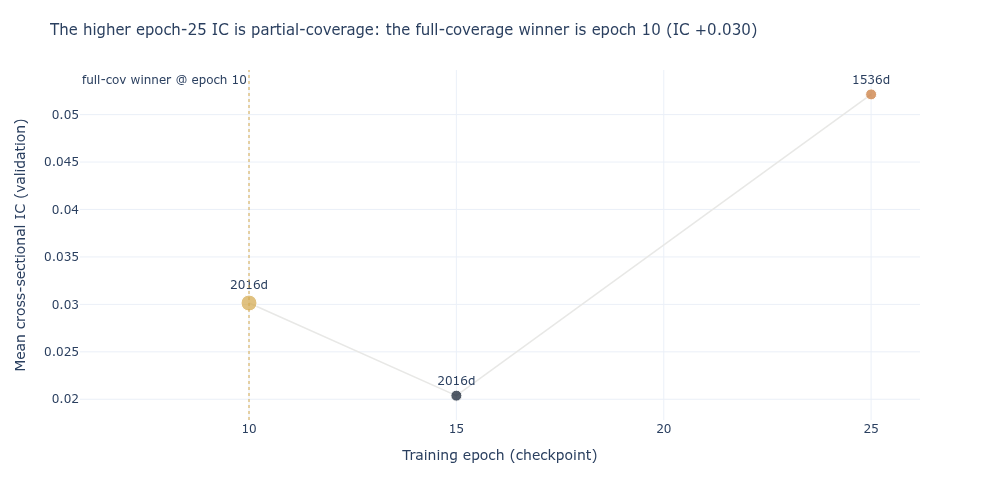

In [9]:
_curve = sorted(best["curve"], key=lambda c: c["epoch"]) if best else []
if _curve:
    _epochs = [c["epoch"] for c in _curve]
    _ics = [c["ic_mean"] for c in _curve]
    _nd = [c["ic_n_days"] for c in _curve]
    _mk_color = [
        COLORS["amber"]
        if c["epoch"] == best_epoch
        else (COLORS["copper"] if c["epoch"] in best["partial_epochs"] else COLORS["blue"])
        for c in _curve
    ]
    _mk_size = [16 if c["epoch"] == best_epoch else 11 for c in _curve]
    fig_lc = go.Figure()
    fig_lc.add_trace(
        go.Scatter(
            x=_epochs,
            y=_ics,
            mode="lines+markers+text",
            line=dict(color=COLORS["silver_muted"], width=1.5),
            marker=dict(color=_mk_color, size=_mk_size, line=dict(color="white", width=1)),
            text=[f"{d:.0f}d" for d in _nd],
            textposition="top center",
            showlegend=False,
        )
    )
    fig_lc.add_vline(
        x=best_epoch,
        line=dict(color=COLORS["amber"], width=1, dash="dot"),
        annotation_text=f"full-cov winner @ epoch {best_epoch}",
        annotation_position="top left",
    )
    fig_lc.update_layout(
        title=(
            f"The higher epoch-25 IC is partial-coverage: "
            f"the full-coverage winner is epoch {best_epoch} (IC {best_ic:+.3f})"
        ),
        template="plotly_white",
        height=500,
        width=1000,
        margin=dict(t=70),
        title_font=dict(size=15),
    )
    fig_lc.update_xaxes(title_text="Training epoch (checkpoint)")
    fig_lc.update_yaxes(title_text="Mean cross-sectional IC (validation)")
    fig_lc.show()

## 6. Comparison Against the Baselines

The full-coverage LSTM checkpoint against the Ridge (Ch11) and GBM (Ch12)
leaders on the same label and validation split. The LSTM sits below both: on
this cross-section sequential memory does not add IC over a heavily regularized
linear model or a shallow-tree GBM.

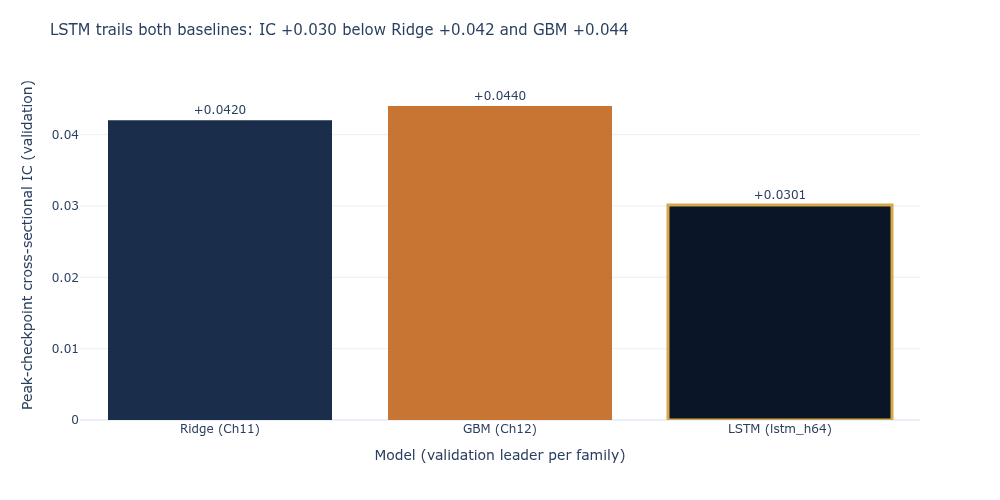

In [10]:
ridge_ic = prior_baselines.get("Ridge (Ch11)", float("nan"))
gbm_ic = prior_baselines.get("GBM (Ch12)", float("nan"))

_labels = ["Ridge (Ch11)", "GBM (Ch12)", f"LSTM ({best_name})"]
_vals = [ridge_ic, gbm_ic, best_ic]
_colors = [COLORS["slate"], COLORS["copper"], COLORS["blue"]]
_line_w = [0, 0, 3]  # outline the LSTM bar to draw the eye
fig_cmp = go.Figure(
    go.Bar(
        x=_labels,
        y=_vals,
        marker=dict(color=_colors, line=dict(color=COLORS["amber"], width=_line_w)),
        text=[f"{v:+.4f}" for v in _vals],
        textposition="outside",
        cliponaxis=False,
        showlegend=False,
    )
)
fig_cmp.update_layout(
    title=(
        f"LSTM trails both baselines: IC {best_ic:+.3f} "
        f"below Ridge {ridge_ic:+.3f} and GBM {gbm_ic:+.3f}"
    ),
    template="plotly_white",
    height=500,
    width=1000,
    margin=dict(t=70),
    title_font=dict(size=15),
)
fig_cmp.update_xaxes(title_text="Model (validation leader per family)")
fig_cmp.update_yaxes(title_text="Peak-checkpoint cross-sectional IC (validation)")
fig_cmp.show()

In [11]:
dl_delta = best_ic - ridge_ic
print(f"LSTM full-coverage IC:   {best_ic:+.4f}  (epoch {best_epoch})")
print(f"Ridge (Ch11):            {ridge_ic:+.4f}")
print(f"GBM (Ch12):              {gbm_ic:+.4f}")
print(f"LSTM - Ridge delta:      {dl_delta:+.4f}")

LSTM full-coverage IC:   +0.0301  (epoch 10)
Ridge (Ch11):            +0.0420
GBM (Ch12):              +0.0440
LSTM - Ridge delta:      -0.0119


## 7. Winner Fold Metrics & Registered Predictions

The winner's validation IC is the mean of its per-fold cross-sectional IC. The
fold breakdown, read from the frozen registry, shows the modest average is
uneven - carried by a few folds and negative on two - and the winner's
prediction set is already persisted for the backtest to read directly. No
retraining or re-saving happens on a cached checkout.

In [12]:
if best and best.get("best_prediction_hash"):
    con = sqlite3.connect(CASE_DIR / "run_log" / "registry.db")
    try:
        fold_rows = con.execute(
            "SELECT fold_id, ic, n_entities FROM fold_metrics "
            "WHERE prediction_hash = ? ORDER BY fold_id",
            (best["best_prediction_hash"],),
        ).fetchall()
    finally:
        con.close()
    print(f"Per-fold validation IC ({best_name} @ epoch {best_epoch}):")
    for fold_id, ic, n_ent in fold_rows:
        print(f"  Fold {fold_id}: IC={ic:+.4f}  n_entities={int(n_ent)}")
    _fold_mean = float(np.mean([r[1] for r in fold_rows])) if fold_rows else float("nan")
    print(f"\n  Mean fold IC: {_fold_mean:+.4f}  (registered peak IC: {best_ic:+.4f})")
    print(f"  Winner prediction_hash: {best['best_prediction_hash']}")

Per-fold validation IC (lstm_h64 @ epoch 10):
  Fold 0: IC=+0.0624  n_entities=96
  Fold 1: IC=+0.0302  n_entities=97
  Fold 2: IC=+0.0437  n_entities=96
  Fold 3: IC=-0.0045  n_entities=97
  Fold 4: IC=+0.0498  n_entities=97
  Fold 5: IC=+0.0370  n_entities=96
  Fold 6: IC=-0.0240  n_entities=94
  Fold 7: IC=+0.0465  n_entities=90

  Mean fold IC: +0.0301  (registered peak IC: +0.0301)
  Winner prediction_hash: affdaa459d15


## 8. MC Dropout Uncertainty (Optional)

In [13]:
if MC_DROPOUT:
    from ml4t.diagnostic.metrics import cross_sectional_ic

    from case_studies.utils.deep_learning import mc_dropout_predict
    from case_studies.utils.sequence_dataset import (
        materialize_sequences,
        prepare_fold_sequence_stores,
    )

    dates_series = dataset_pd[date_col]
    last_fold = splits[-1]
    train_mask = (dates_series >= last_fold["train_start"]) & (
        dates_series <= last_fold["train_end"]
    )
    val_mask = (dates_series >= last_fold["val_start"]) & (dates_series <= last_fold["val_end"])

    train_store, val_store, _ = prepare_fold_sequence_stores(
        dataset_pd,
        train_mask=train_mask,
        val_mask=val_mask,
        feature_names=feature_names,
        label_col=label_col,
        date_col=date_col,
        entity_col=entity_col,
        lookback=LOOKBACK,
    )
    X_train_seq, y_train_seq, _, _ = materialize_sequences(train_store)
    X_val_seq, y_val_seq, val_dates, val_entities = materialize_sequences(val_store)

    if len(X_train_seq) > 0 and len(X_val_seq) > 0:
        torch_device = torch.device(device_str)
        best_cfg_dict = dl_configs[0]
        arch_name = best_cfg_dict["params"].get(
            "architecture", _resolve_arch_name(best_cfg_dict["config_name"])
        )
        from case_studies.utils.deep_learning import _build_arch_kwargs

        best_cfg = _build_arch_kwargs(
            best_cfg_dict, n_features, best_cfg_dict["params"].get("lookback", 60)
        )
        mc_model = create_model(arch_name, best_cfg).to(torch_device)

        X_t = torch.FloatTensor(X_train_seq).to(torch_device)
        y_t = torch.FloatTensor(y_train_seq).to(torch_device)
        optimizer = torch.optim.AdamW(mc_model.parameters(), lr=1e-3)
        criterion = torch.nn.MSELoss()

        mc_model.train()
        for ep in range(min(N_EPOCHS, 50)):
            idx = torch.randperm(len(X_t))
            for s in range(0, len(X_t), BATCH_SIZE):
                batch = idx[s : s + BATCH_SIZE]
                loss = criterion(mc_model(X_t[batch]), y_t[batch])
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        X_v = torch.FloatTensor(X_val_seq).to(torch_device)
        mean_pred, std_pred = mc_dropout_predict(mc_model, X_v, n_samples=50)

        median_unc = np.median(std_pred)
        low_unc = std_pred <= median_unc
        high_unc = std_pred > median_unc

        low_frame = pl.DataFrame(
            {
                "date": val_dates[low_unc],
                "symbol": val_entities[low_unc],
                "y_true": y_val_seq[low_unc],
                "y_pred": mean_pred[low_unc],
            }
        )
        ic_low = cross_sectional_ic(
            low_frame,
            low_frame,
            pred_col="y_pred",
            ret_col="y_true",
            date_col="date",
            entity_col="symbol",
            min_obs=5,
        )["ic_mean"]
        high_frame = pl.DataFrame(
            {
                "date": val_dates[high_unc],
                "symbol": val_entities[high_unc],
                "y_true": y_val_seq[high_unc],
                "y_pred": mean_pred[high_unc],
            }
        )
        ic_high = cross_sectional_ic(
            high_frame,
            high_frame,
            pred_col="y_pred",
            ret_col="y_true",
            date_col="date",
            entity_col="symbol",
            min_obs=5,
        )["ic_mean"]
        print("MC Dropout uncertainty analysis:")
        print(f"  Low uncertainty IC:  {ic_low:+.4f} ({low_unc.sum():,} samples)")
        print(f"  High uncertainty IC: {ic_high:+.4f} ({high_unc.sum():,} samples)")
        print(f"  IC gap: {ic_low - ic_high:+.4f}")

        del mc_model, X_t, y_t, X_v
        torch.cuda.empty_cache()
else:
    print("MC Dropout disabled (set MC_DROPOUT=True to enable)")

MC Dropout disabled (set MC_DROPOUT=True to enable)


## 9. Key Takeaways

- **LSTM does not beat the flat-feature baselines here.** Its full-coverage
  winner is the **epoch-10** checkpoint at validation IC $\approx +0.030$, below
  both the Ridge leader ($\approx +0.042$ from [`06_linear`](06_linear.ipynb))
  and the GBM leader (`leaves_7_mae`, $\approx +0.044$ from
  [`07_gbm`](07_gbm.ipynb)). Without cross-asset channel mixing the LSTM treats
  each ETF's feature history independently and cannot learn the lead-lag
  relationships that are TSMixer's strength; on this panel most temporal
  structure in monthly ETF returns is already captured by the linear lookback
  features engineered in Ch8.
- **The higher raw IC at epoch 25 is a coverage artifact, not a better model.**
  That checkpoint scores $+0.052$ but on only 1{,}536 of the 2{,}016 full-coverage
  validation days - its predictions collapse to near-constant on some folds, so
  the IC is measured on a different, smaller set of days and is not comparable.
  The full-coverage guard excludes it, which is why the reported winner is the
  lower but full-coverage epoch-10 checkpoint.
- **The edge is fold-fragile and does not generalize.** The epoch-10 validation
  IC is the mean of uneven per-fold ICs, negative on two of the eight folds.
  On the sealed 2024-2025 holdout the frozen LSTM checkpoint posts a **negative**
  IC ($\approx -0.032$, evaluated once in [`13_model_analysis`](13_model_analysis.ipynb)),
  so even the modest validation signal does not survive out of sample.

**Next**: [`10_dl_tsmixer`](10_dl_tsmixer.ipynb) tests whether explicit cross-asset feature mixing
captures the lead-lag structure that LSTM misses.
**Book**: Chapter 13, Section 13.8 (Case Study Results).